# Initial Conditions - MEOP

In this Notebook, I create binary files for the initial conditions of my model study for temperature and salinity based on MEOP Profiles from Haumann et al. (2020).

##  Import Packages

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import xmitgcm.utils
import gsw as gsw
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

import mat73 # for loading .mat files version >= 7.3

## Load Data

In [2]:
filepath = "/isibhv/projects-noreplica/p_so-clim/alhaum001/supercool_profiles_merged_20200911.mat"
matstructs= mat73.loadmat(filepath) # this loads the matlab file as a python dictionary
matstructs.keys() # the dictionary keys (the names of the mat structures in the .mat file)

dict_keys(['data0', 'data1', 'data1_other', 'data2'])

In [3]:
data1 = matstructs['data1']
data1_other = matstructs['data1_other']
data2 = matstructs['data2']

- data1: metadata of the supercooled profiles
- data1_other: metadata non-supercooled profiles
- data2: the supercooled profiles

### Add Datetime

In [4]:
# add datetime variable
zero_time = datetime(1,1,1) # Matlab's day zero is 0000-01-01, but Python's datetime starts at 0001-01-01, so we need to account for that when converting

# DATA1
days = data1["dates"]-1-366 # convert from Matlab's datenum to number of days since 0001-01-01, accounting for the fact that Matlab's datenum starts with 1 at 0000-01-01 and includes a leap year in year 0
datetimes = [
    zero_time + timedelta(days=day) if day == day else float('nan') # convert to datetime, respecting NaN values
    for day in days
]

data1["datetimes"] = pd.Series(np.array(datetimes))

# DATA1_OTHER
days_other = data1_other["dates"]-1-366
datetimes_other = [
    zero_time + timedelta(days=day) if day == day else float('nan')
    for day in days_other
]

data1_other["datetimes"] = pd.Series(np.array(datetimes_other))


### Filter for Seal 9900109

In [5]:
mask_9900109 = (data1["id"] == 9900109)

data1_9900109 = {key: data1[key][mask_9900109] for key in data1.keys()}
data2_9900109 = {key: data2[key][:,mask_9900109] for key in data2.keys()}

mask_other_9900109 = (data1_other["id"] == 9900109)
data1_other_9900109 = {key: data1_other[key][mask_other_9900109] for key in data1_other.keys()}

print("Total number of profiles: ", len(data1_9900109["datetimes"])+len(data1_other_9900109["datetimes"]))
print("Number of supercooled profiles: ", len(data1_9900109["datetimes"]))
print("Number of profiles without supercooling: ", len(data1_other_9900109["datetimes"]))
print(f"Ratio: {len(data1_9900109["datetimes"])/(len(data1_9900109["datetimes"])+len(data1_other_9900109["datetimes"]))*100:.0f} %")

Total number of profiles:  620
Number of supercooled profiles:  209
Number of profiles without supercooling:  411
Ratio: 34 %


## Select Profile

We want the Profile from 2008-07-16 08

In [6]:
date = datetime(2008,7,16,8)

mask = (data1_9900109['datetimes'] > date) & (data1_9900109['datetimes'] < (date + timedelta(hours=1)))

profile_data1 = pd.DataFrame(data1_9900109)[mask]

data2_profile = {key: data2_9900109[key][:, mask].flatten() 
     for key in data2_9900109 
     if key not in ["dpth_mid","n2", "prs_mid"]} # exclude all variables that are shorter by 1
profile_df = pd.DataFrame.from_dict(data2_profile)
profile_df.columns

Index(['cp', 'def_pt0', 'def_pt0_err', 'def_t', 'def_t_err', 'dpth', 'ds',
       'dt', 'gamman', 'prs', 'prs_err', 'pt0', 'pt0_err', 'rho', 's', 's_err',
       'sigma0', 't', 't_err', 't_freeze', 't_freeze0', 't_freeze0_err',
       't_freeze_err'],
      dtype='object')

## Calculate Absolute Salinity

In [7]:
# calculate ABSOLUTE SALINITY
profile_df["SA"] = gsw.conversions.SA_from_SP(profile_df["s"], profile_df["prs"], profile_data1["lon"].iloc[0], profile_data1["lat"].iloc[0]) # (g/kg)

# calculate CONSERVATIVE TEMPERATURE
# profile_df["ct"] = gsw.conversions.CT_from_pt(profile_df["SA"], profile_df["pt0"]) # (°C)

## Interpolate to grid

In [8]:
# z grid distances from MITgcm file data
delZ = np.array(
    [1.0,  1.1,  1.2,  1.2,  1.3,  1.3,  1.4,  1.4,  1.5,  1.6,
    1.7,  1.7,  1.8,  1.9,  2.0,  2.1,  2.2,  2.3,  2.4,  2.5,
    2.6,  2.8,  2.9,  3.0,  3.2,  3.3,  3.5,  3.6,  3.8,  4.0,
    4.2,  4.4,  4.6,  4.8,  5.0,  5.2,  5.5,  5.8,  6.0,  6.3,
    6.6,  6.9,  7.2,  7.6,  7.9,  8.3,  8.7,  9.1,  9.5,  10.0,])

zs = delZ.cumsum()
profile_interp = pd.DataFrame()
profile_interp["dpth"] = zs
profile_interp["pt0"] = np.interp(zs, profile_df["dpth"].values, profile_df["pt0"])
profile_interp["SA"] = np.interp(zs, profile_df["dpth"].values, profile_df["SA"])
profile_interp["t_freeze0"] = np.interp(zs, profile_df["dpth"].values, profile_df["t_freeze0"])

## Erase Supercooling

In [9]:
mask = profile_interp.pt0 < profile_interp.t_freeze0
profile_interp["pt0_noSC"] = profile_interp["pt0"]
profile_interp.loc[mask, "pt0_noSC"] = profile_interp.t_freeze0

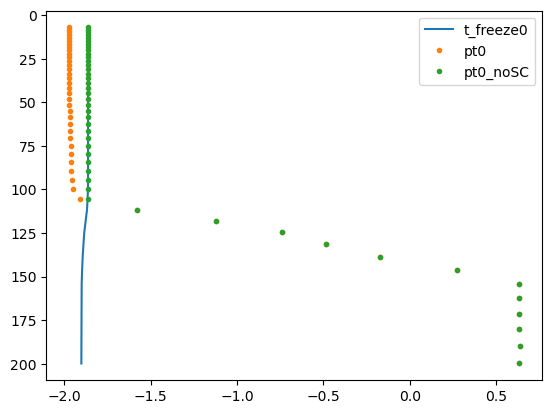

In [10]:
# control plot 
plt.plot(profile_interp.t_freeze0, profile_interp.dpth, label = "t_freeze0")
plt.plot(profile_interp.pt0, profile_interp.dpth, ".", label = "pt0")
plt.plot(profile_interp.pt0_noSC, profile_interp.dpth, ".", label = "pt0_noSC")


plt.gca().invert_yaxis()
# plt.ylim(150,0)
# plt.xlim(-2.3,-1.5)
plt.legend()

## Fill NaNs at surface

In [11]:
profile_interp.loc[0:5,:] = profile_interp.loc[5,:].values
# count remaining nans
profile_interp.isnull().sum()

dpth         0
pt0          0
SA           0
t_freeze0    0
pt0_noSC     0
dtype: int64

## Write Initial Conditions to Binaries

See https://xmitgcm.readthedocs.io/en/latest/demo_writing_binary_file.html and https://github.com/rowanjb/PhD_model_analysis/blob/main/binaries.py

In [13]:
Nx = 50 # east-west
Ny = 100 # north-south
Nz = len(profile_interp.index)

In [49]:
dir_binaries = "../../MITgcm/so_plumes/input/"
prefix = "init_"

# suffix containing profile date
suffix = "_MEOP_" + date.strftime('%Y-%m-%d_%H:%M') + f"_Nx{Nx}_Ny{Ny}_Nz{Nz}"

# potential temperature
t_gridded = np.tile(profile_interp["pt0"], (Nx,Ny,1)) # shape:  X,Y,Z
filename = prefix +'pt'+suffix+".bin"
xmitgcm.utils.write_to_binary(t_gridded.flatten(order='F'), dir_binaries+filename)
print("Wrote:", filename)

# potential temperature without SC
t_gridded = np.tile(profile_interp["pt0_noSC"], (Nx,Ny,1)) # shape: X,Y,Z
filename = prefix +'pt_noSC'+suffix+".bin"
xmitgcm.utils.write_to_binary(t_gridded.flatten(order='F'), dir_binaries+filename)
print("Wrote:", filename)

# absolute salinity
s_gridded = np.tile(profile_interp["SA"], (Nx,Ny,1)) # shape: X,Y,Z
filename = prefix +'SA'+suffix+".bin"
xmitgcm.utils.write_to_binary(s_gridded.flatten(order='F'), dir_binaries+filename)
print("Wrote:", filename)

Wrote: init_pt_MEOP_2008-07-16_08:00_Nx50_Ny100_Nz50.bin
Wrote: init_pt_noSC_MEOP_2008-07-16_08:00_Nx50_Ny100_Nz50.bin
Wrote: init_SA_MEOP_2008-07-16_08:00_Nx50_Ny100_Nz50.bin


## Write Boundary Conditions to Binaries

Format $N_x \times N_r \times t$ for North / South Boundary

In [34]:
t = 36

dir_binaries = "../../MITgcm/so_plumes/input/"
prefix = "boundary_"
# suffix containing profile date
suffix = "_MEOP_" + date.strftime('%Y-%m-%d_%H:%M') + f"_Nx{Nx}_Nz{Nz}_Nt{t}"

# potential temperature
t_boundary = np.empty((Nx, Nz, t))
t_boundary[:] = np.array(profile_interp["pt0"])[None, :, None]
filename = prefix +'pt'+suffix+".bin"
xmitgcm.utils.write_to_binary(t_boundary.flatten(order='F'), dir_binaries+filename)
print("Wrote:", filename)

# potential temperature without SC
t_boundary = np.empty((Nx, Nz, t))
t_boundary[:] = np.array(profile_interp["pt0_noSC"])[None, :, None]
filename = prefix +'pt_noSC'+suffix+".bin"
xmitgcm.utils.write_to_binary(t_boundary.flatten(order='F'), dir_binaries+filename)
print("Wrote:", filename)

# absolute salinity
s_boundary = np.empty((Nx, Nz, t))
s_boundary[:] = np.array(profile_interp["SA"])[None, :, None]
filename = prefix +'SA'+suffix+".bin"
xmitgcm.utils.write_to_binary(s_boundary.flatten(order='F'), dir_binaries+filename)
print("Wrote:", filename)


Wrote: boundary_pt_MEOP_2008-07-16_08:00_Nx50_Nz50_Nt36.bin
Wrote: boundary_pt_noSC_MEOP_2008-07-16_08:00_Nx50_Nz50_Nt36.bin
Wrote: boundary_SA_MEOP_2008-07-16_08:00_Nx50_Nz50_Nt36.bin
